In [1]:
import pandas as pd

In [2]:
dataframe=pd.read_csv('AQI new.csv')

In [3]:
dataframe.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00:00,16.554731,80.649110,SO2,20.0,23.0,21.0
1,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00:00,16.554731,80.649110,OZONE,17.0,35.0,22.0
2,India,Andhra_Pradesh,Visakhapatnam,"GVM Corporation, Visakhapatnam - APPCB",19-05-2025 10:00:00,17.720000,83.300000,PM10,23.0,66.0,36.0
3,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00:00,27.103358,93.679645,NO2,4.0,5.0,5.0
4,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00:00,27.103358,93.679645,CO,10.0,19.0,12.0


In [4]:
df=dataframe[['country','state','city','station','last_update','pollutant_id','pollutant_min','pollutant_max','pollutant_avg']]

In [5]:
df.columns=['country','state','city','station','last_update','poll_id','poll_min','poll_max','poll_avg']

In [6]:
df.loc[:,"values"]=(df['poll_min']+df['poll_max'])/2
df.head()

C:\Users\MYPC\AppData\Local\Temp\ipykernel_15088\181803334.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,"values"]=(df['poll_min']+df['poll_max'])/2


,country,state,city,station,last_update,poll_id,poll_min,poll_max,poll_avg,values
0,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00:00,SO2,20.0,23.0,21.0,21.5
1,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00:00,OZONE,17.0,35.0,22.0,26.0
2,India,Andhra_Pradesh,Visakhapatnam,"GVM Corporation, Visakhapatnam - APPCB",19-05-2025 10:00:00,PM10,23.0,66.0,36.0,44.5
3,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00:00,NO2,4.0,5.0,5.0,4.5
4,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00:00,CO,10.0,19.0,12.0,14.5


In [7]:
df_pivot=df.pivot_table(index=["country","state","city","station","last_update","poll_min","poll_max","values"],columns="poll_id",values="poll_avg").reset_index()

In [8]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2770 entries, 0 to 2769
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      2770 non-null   object 
 1   state        2770 non-null   object 
 2   city         2770 non-null   object 
 3   station      2770 non-null   object 
 4   last_update  2770 non-null   object 
 5   poll_min     2770 non-null   float64
 6   poll_max     2770 non-null   float64
 7   values       2770 non-null   float64
 8   CO           424 non-null    float64
 9   NH3          357 non-null    float64
 10  NO2          403 non-null    float64
 11  OZONE        419 non-null    float64
 12  PM10         392 non-null    float64
 13  PM2.5        393 non-null    float64
 14  SO2          390 non-null    float64
dtypes: float64(10), object(5)
memory usage: 324.7+ KB


In [9]:
#select only numeric columns
numeric_col=df_pivot.select_dtypes(include=['number']).columns
# fill mean only in numeric columns
#df_pivot[numeric_col]=df_pivot[numeric_col].fillna(df_pivot[numeric_col].mean())
#df_pivot.head()

In [10]:
df_pivot.head()

poll_id,country,state,city,station,last_update,poll_min,poll_max,values,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
0,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,1.0,15.0,8.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN
1,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,2.0,35.0,18.5,NaN,NaN,NaN,NaN,NaN,NaN,21.0
2,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,3.0,18.0,10.5,NaN,NaN,NaN,7.0,NaN,NaN,NaN
3,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,5.0,30.0,17.5,NaN,NaN,NaN,NaN,17.0,NaN,NaN
4,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,17.0,38.0,27.5,20.0,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_pivot[['CO','NH3','NO2','OZONE','PM10','PM2.5','SO2']]=df_pivot[['CO','NH3','NO2','OZONE','PM10','PM2.5','SO2']].fillna(df_pivot[['CO','NH3','NO2','OZONE','PM10','PM2.5','SO2']].mean())

In [12]:
df_pivot.head()

poll_id,country,state,city,station,last_update,poll_min,poll_max,values,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
0,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,1.0,15.0,8.0,31.198113,5.403361,23.82134,25.868735,77.762755,5.000000,14.671795
1,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,2.0,35.0,18.5,31.198113,5.403361,23.82134,25.868735,77.762755,57.167939,21.000000
2,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,3.0,18.0,10.5,31.198113,5.403361,23.82134,7.000000,77.762755,57.167939,14.671795
3,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,5.0,30.0,17.5,31.198113,5.403361,23.82134,25.868735,17.000000,57.167939,14.671795
4,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",19-05-2025 10:00:00,17.0,38.0,27.5,20.000000,5.403361,23.82134,25.868735,77.762755,57.167939,14.671795


In [13]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2770 entries, 0 to 2769
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      2770 non-null   object 
 1   state        2770 non-null   object 
 2   city         2770 non-null   object 
 3   station      2770 non-null   object 
 4   last_update  2770 non-null   object 
 5   poll_min     2770 non-null   float64
 6   poll_max     2770 non-null   float64
 7   values       2770 non-null   float64
 8   CO           2770 non-null   float64
 9   NH3          2770 non-null   float64
 10  NO2          2770 non-null   float64
 11  OZONE        2770 non-null   float64
 12  PM10         2770 non-null   float64
 13  PM2.5        2770 non-null   float64
 14  SO2          2770 non-null   float64
dtypes: float64(10), object(5)
memory usage: 324.7+ KB


In [14]:
#import matplotlib.pyplot as plt
#import seaborn as sns

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='last_update'>

<Figure size 1000x20000 with 0 Axes>

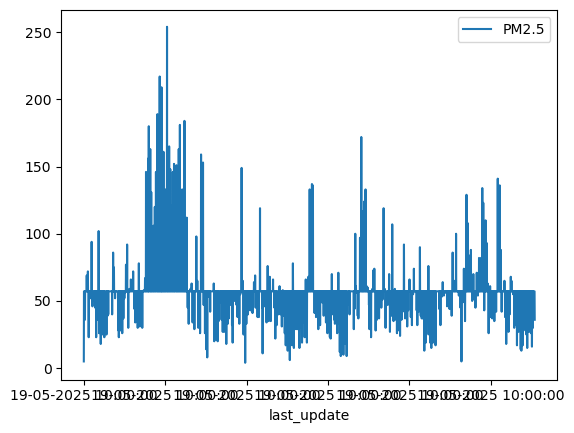

In [16]:
plt.figure(figsize=(10,200))
df_pivot.plot(x='last_update',y='PM2.5',kind='line')

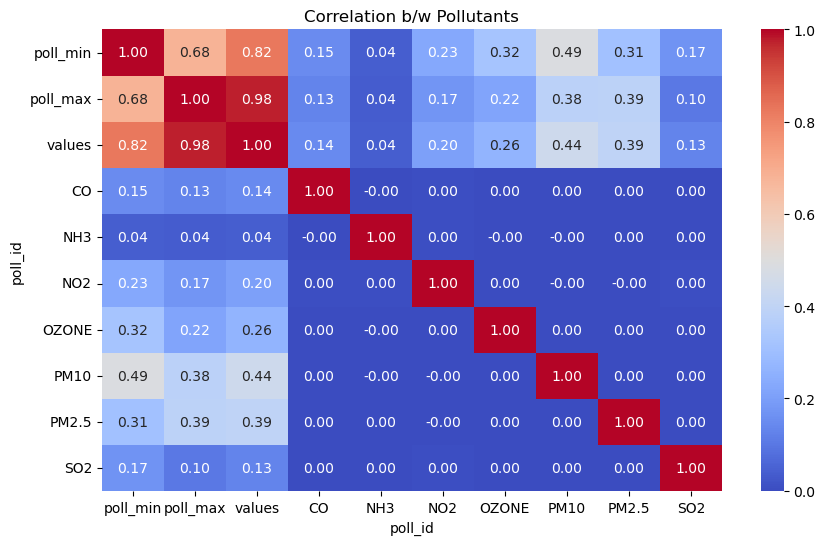

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df_pivot[numeric_col].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation b/w Pollutants")
plt.show()

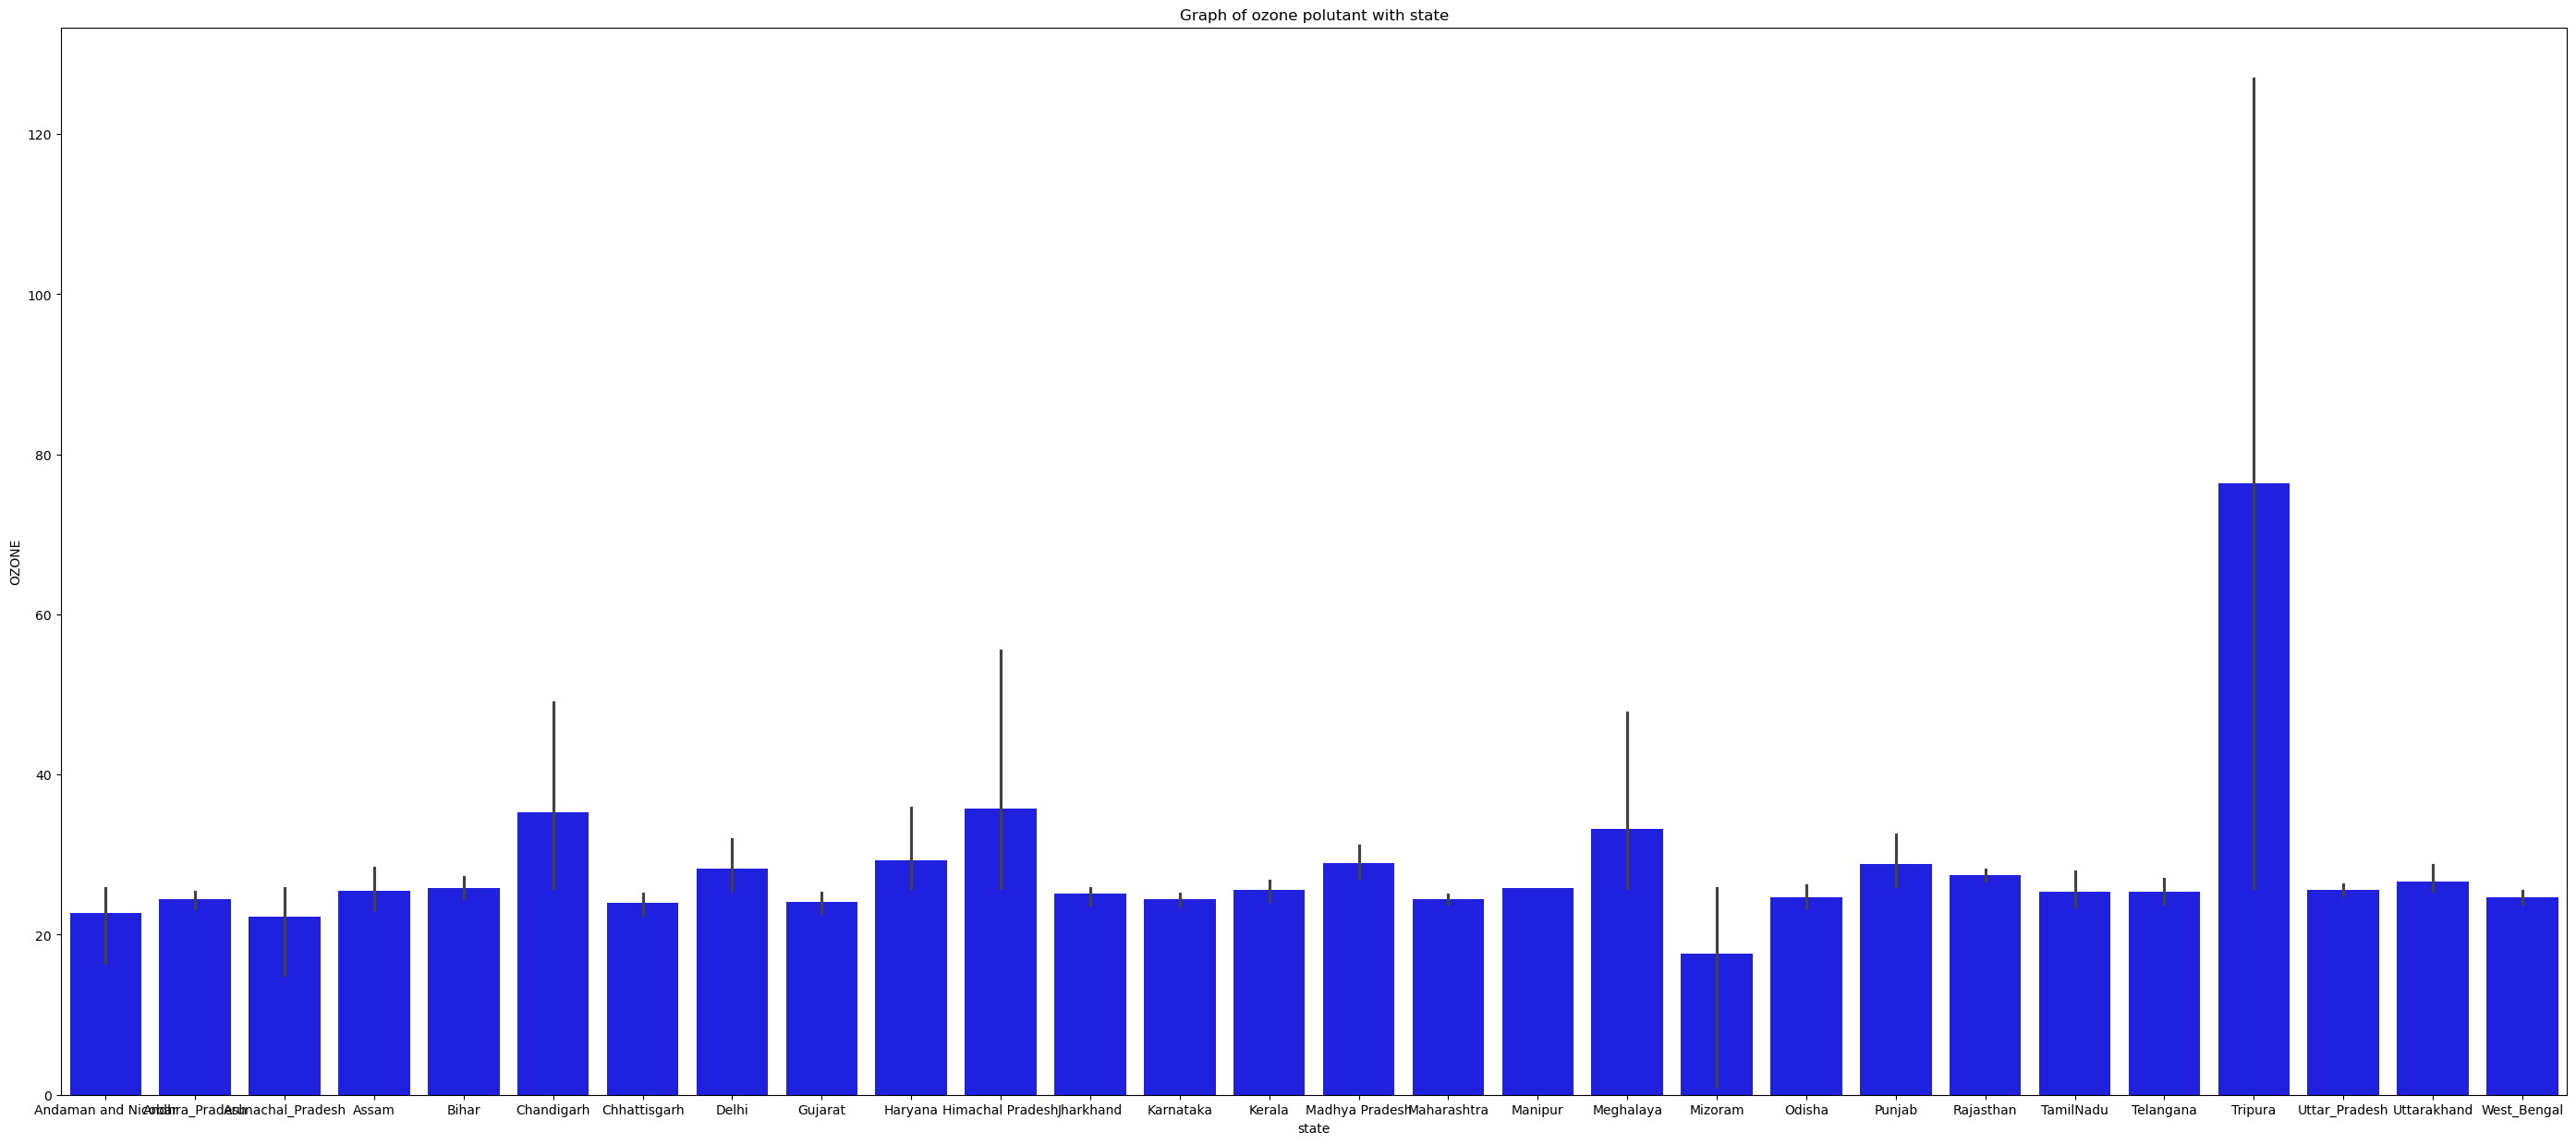

In [18]:
plt.figure(figsize=(35,15))
sns.barplot(x="state",y="OZONE",data=df_pivot, color="blue")
plt.title("Graph of ozone polutant with state")
plt.show()

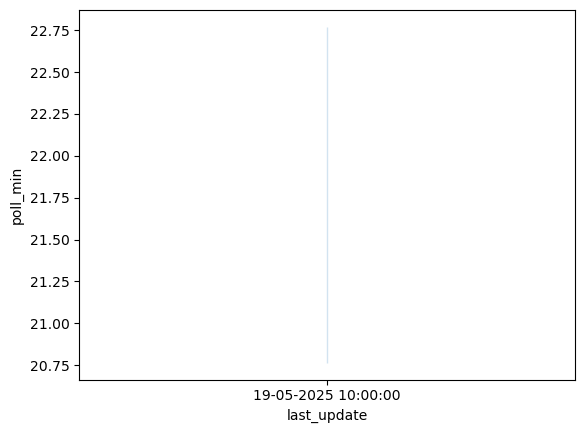

In [19]:
sns.lineplot(x="last_update",y="poll_min",data=df_pivot)
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x=df_pivot[['CO','NH3','NO2','OZONE','PM10','PM2.5','SO2']]
y=df_pivot[['values']]

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
x_train.head()

poll_id,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
315,53.000000,5.403361,23.82134,25.868735,77.762755,57.167939,14.671795
1869,31.198113,5.403361,23.82134,25.868735,113.000000,57.167939,14.671795
1576,31.198113,5.403361,23.82134,25.868735,27.000000,57.167939,14.671795
1336,31.198113,4.000000,23.82134,25.868735,77.762755,57.167939,14.671795
655,31.198113,5.403361,23.82134,25.868735,77.762755,59.000000,14.671795


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [25]:
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)

In [56]:
rf=RandomForestRegressor()
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)

C:\Users\MYPC\anaconda2\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [27]:
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred_dt=dt.predict(x_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
print("MAE:", mean_absolute_error(